<a href="https://colab.research.google.com/github/pelinakbas23/prf-modeling/blob/main/prf-modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/VU-Cog-Sci/prfpy.git


  Cloning https://github.com/VU-Cog-Sci/prfpy.git to /tmp/pip-req-build-n0v1hwwf
  Running command git clone --filter=blob:none --quiet https://github.com/VU-Cog-Sci/prfpy.git /tmp/pip-req-build-n0v1hwwf
  Resolved https://github.com/VU-Cog-Sci/prfpy.git to commit 68ab6bd135436e70bc08e41a0b3c923a59fc6b7b
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as pl
from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel, Norm_Iso2DGaussianModel, DoG_Iso2DGaussianModel, CSS_Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter, Norm_Iso2DGaussianFitter, DoG_Iso2DGaussianFitter, CSS_Iso2DGaussianFitter

ModuleNotFoundError: No module named 'imp'

This notebook shows a simple example of prfpy use

# Creating stimulus object

In [ ]:
#just a random design matrix for teting purposes
screen_size_cm=40
screen_distance_cm=200
#dimensions are pixels, pixels, time
design_matrix=np.zeros((50,50,100))
design_matrix[:,20:30,40:50] = 1
TR=1
task_lengths=[100]
task_names=['test']

#these are the parts of the timecourses that will be used to estimate the baseline
late_iso_dict={'test':np.arange(40)}

normalize_integral_dx=False

prf_stim = PRFStimulus2D(screen_size_cm=screen_size_cm,
                             screen_distance_cm=screen_distance_cm,
                             design_matrix=design_matrix,
                             TR=TR,
                             task_lengths=task_lengths,
                             task_names=task_names,
                             late_iso_dict=late_iso_dict,
                             normalize_integral_dx=normalize_integral_dx)

# Gaussian model fit

## Creating Gaussian model and fitter objects

In [ ]:
#only does something if filtering predictions
filter_type='dc'
filter_params={"first_modes_to_remove":3,
                         "last_modes_to_remove_percent":0,
                         "window_length":50,
                         "polyorder":3,
                         "highpass":True,
                         "add_mean":True}

filter_predictions=False

#setting a default hrf (this will not be used if we then decide to fit the hrf)
hrf=[1,2,0]
#SPM or TDM (kendrick kay) as hrf basis
hrf_basis='SPM'
#HRF amplitude set to 1 or not
normalize_hrf=True

normalize_RFs=False

#some kind of fake data
data = 3*np.random.rand(50,100)+0.01*np.sum(design_matrix, axis=(0,1))-1.5
data[:10,30:40] -= 2.5
data[:10,50:60] -= 2
data = np.roll(data,12)


gg = Iso2DGaussianModel(stimulus=prf_stim,
                          hrf=hrf,
                          filter_predictions=filter_predictions,
                          filter_type=filter_type,
                          filter_params=filter_params,
                          normalize_RFs=normalize_RFs,
                          hrf_basis=hrf_basis,
                          normalize_hrf=normalize_hrf)

gf = Iso2DGaussianFitter(data=data, model=gg, n_jobs=8)

## Gaussian grid fit

In [ ]:
#ecc-polar-size grids
ecc_grid=np.linspace(0,10,10)
polar_grid=np.linspace(-np.pi,np.pi,10)
size_grid=np.linspace(1,10,10)

verbose=False
n_batches=8

#IMPORTANT: fixing bold baseline to 0 (recommended), and only allowing positive prfs
fixed_grid_baseline=0
gauss_grid_bounds=[(0,1000)] #bound on prf amplitudes (only positive)

#hrf parameter grids. keep them like this.
hrf_1_grid=np.linspace(0,10,10)
#hrf_2 should always be fixed to 0, unless you have a very good reason to vary it and you know what you are doing
hrf_2_grid=np.linspace(0,0,1)

gf.grid_fit(ecc_grid=ecc_grid,
                polar_grid=polar_grid,
                size_grid=size_grid,
                verbose=verbose,
                n_batches=n_batches,
                fixed_grid_baseline=fixed_grid_baseline,
                grid_bounds=gauss_grid_bounds,
                hrf_1_grid=hrf_1_grid,
                hrf_2_grid=hrf_2_grid)

## Gaussian Iterative Fit

In [ ]:
rsq_threshold=0.05
verbose=True
gauss_bounds = [(-1.5*10, 1.5*10),  # x
                (-1.5*10, 1.5*10),  # y
                (0.1, 1.5*5),  # prf size
                (0, 1000),  # prf amplitude
                (0, 0)]  # bold baseline
gauss_bounds += [(0,10),(0,0)] #hrf bounds. if want it fixed to some value, specify e.g. (4,4) (0,0)
constraints=None
tol=1e-4
xtol=1e-4

#iterative fit acts as a wrapper of optimize.minimize and passes all the arguments
gf.iterative_fit(rsq_threshold=rsq_threshold, verbose=verbose,
                         bounds=gauss_bounds,
                         constraints=constraints,
                             tol=tol,
                            method='trust-constr',
                            options={'xtol':xtol})

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  37 out of  37 | elapsed:   50.5s finished


# DN model fit

## Create model and fitter objects

In [ ]:
from prfpy.model import Iso2DGaussianModel, Norm_Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter, Norm_Iso2DGaussianFitter

In [ ]:
stimulus=prf_stim
filter_type='dc'
filter_params={"first_modes_to_remove":3,
                         "last_modes_to_remove_percent":0,
                         "window_length":50,
                         "polyorder":3,
                         "highpass":True,
                         "add_mean":True}

filter_predictions=False
normalize_RFs=False

use_previous_gaussian_fitter_hrf=False #if true, will use hrf result from gauss fit at the grid stage instead of doing a grid fit for it

gg_norm = Norm_Iso2DGaussianModel(stimulus=prf_stim,
                                    hrf=hrf,
                                    filter_predictions=filter_predictions,
                                    filter_type=filter_type,
                                    filter_params=filter_params,
                                    normalize_RFs=normalize_RFs,
                                    hrf_basis=hrf_basis,
                                    normalize_hrf=normalize_hrf)

gf_norm = Norm_Iso2DGaussianFitter(data=data,
                                   model=gg_norm,
                                   n_jobs=1,
                                   previous_gaussian_fitter=gf,
                                  use_previous_gaussian_fitter_hrf=use_previous_gaussian_fitter_hrf)

## DN model grid fit

In [ ]:
gf_norm.grid_fit(surround_amplitude_grid=surround_amplitude_grid,
                 surround_size_grid=surround_size_grid,
                 neural_baseline_grid=neural_baseline_grid,
                 surround_baseline_grid=surround_baseline_grid,
                 verbose=verbose,
                 n_batches=1,
                 rsq_threshold=rsq_threshold,
                 fixed_grid_baseline=fixed_grid_baseline,
                 grid_bounds=norm_grid_bounds,
                 hrf_1_grid=hrf_1_grid,
                 hrf_2_grid=hrf_1_grid)

Each batch contains approx. 37 voxels.


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed: 10.6min
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 10.6min finished


In [ ]:
norm_grid_bounds = [(0,1000),(0,1000)] #only prf amplitudes between 0 and 1000, only neural baseline values between 0 and 1000, for consistency with iterative fitting bounds

surround_amplitude_grid=np.array([0.05,0.2,0.4,0.7,1,3], dtype='float32')
surround_size_grid=np.array([3,5,8,12,18], dtype='float32')
neural_baseline_grid=np.array([0,1,10,100], dtype='float32')
surround_baseline_grid=np.array([0.1,1.0,10.0,100.0], dtype='float32')

gf_norm.grid_fit(surround_amplitude_grid=surround_amplitude_grid,
             surround_size_grid=surround_size_grid,
             neural_baseline_grid=neural_baseline_grid,
             surround_baseline_grid=surround_baseline_grid,
             verbose=verbose,
             n_batches=1,
             rsq_threshold=rsq_threshold,
             fixed_grid_baseline=fixed_grid_baseline,
             grid_bounds=norm_grid_bounds,
            hrf_1_grid=hrf_1_grid,
            hrf_2_grid=hrf_1_grid)#,

#if desired, can perform full grid using the parameters below (not recommended)
#                ecc_grid=ecc_grid[:num],
#                polar_grid=polar_grid[:num],
#                size_grid=size_grid[:num])

Each batch contains approx. 37 voxels.


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed: 10.5min
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 10.5min finished


## DN Iterative Fit

In [ ]:
xtol = 1e-4
ftol = 1e-4

In [ ]:
norm_bounds =  [(-1.5*10, 1.5*10),  # x
                (-1.5*10, 1.5*10),  # y
                (0.1, 1.5*5),  # prf size
                (0, 1000),  # prf amplitude
                (0, 0),  # bold baseline (fixed to zero)
                (0, 1000),  # surround amplitude
                (0.1, 3*5),  # surround size
                (0, 1000),  # neural baseline
                (1e-6, 1000)]  # surround baseline
norm_bounds += [(0,10),(0,0)] #hrf bounds
constraints_norm = None

gf_norm.iterative_fit(rsq_threshold=rsq_threshold, verbose=verbose,
                               bounds=norm_bounds,
                               constraints=constraints_norm)

[Parallel(n_jobs=1)]: Done  37 out of  37 | elapsed:    9.0s finished


# Crossvalidate

In [ ]:
test_data = 3*np.random.rand(50,100)+0.01*np.sum(design_matrix, axis=(0,1))-1.5
np.roll(test_data,6)

test_stimulus = prf_stim

single_hrf = False

gf.crossvalidate_fit(test_data=test_data,
                     test_stimulus=test_stimulus,
                     single_hrf=single_hrf)

gf_norm.crossvalidate_fit(test_data,
                        test_stimulus=test_stimulus,
                        single_hrf=single_hrf)

Gaussian fit parametreleri (ilk 5 voksel):
x: [0. 0. 0. 0. 0.]
y: [0. 0. 0. 0. 0.]
sigma: [0. 0. 0. 0. 0.]
R²: [0. 0. 0. 0. 0.]


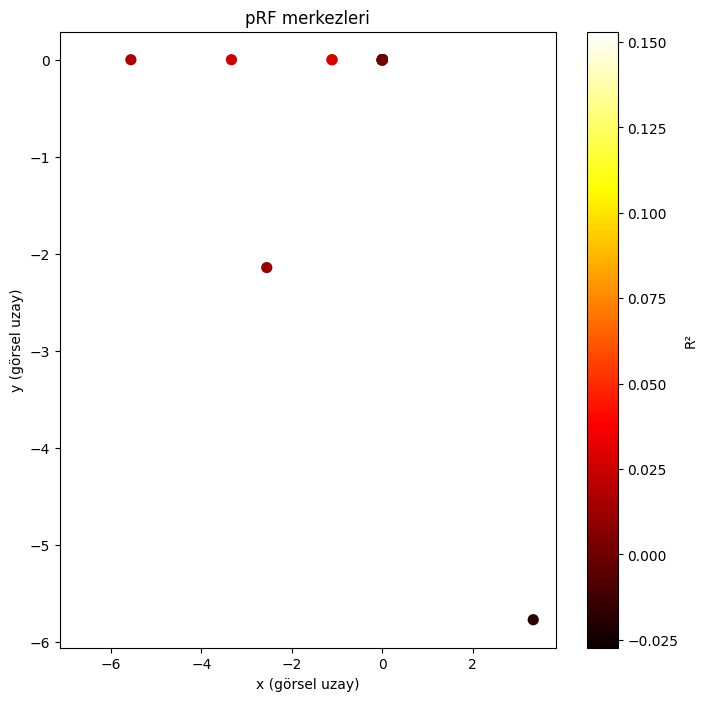

In [ ]:
import matplotlib.pyplot as plt

# Gaussian fit sonuçları
print("Gaussian fit parametreleri (ilk 5 voksel):")
print("x:", gf.iterative_search_params[:5, 0])
print("y:", gf.iterative_search_params[:5, 1])
print("sigma:", gf.iterative_search_params[:5, 2])
print("R²:", gf.iterative_search_params[:5, -1])

# Görselleştir
plt.figure(figsize=(8,8))
plt.scatter(gf.iterative_search_params[:, 0],
            gf.iterative_search_params[:, 1],
            c=gf.iterative_search_params[:, -1],
            cmap='hot', s=50)
plt.colorbar(label='R²')
plt.xlabel('x (görsel uzay)')
plt.ylabel('y (görsel uzay)')
plt.title('pRF merkezleri')
plt.show()